In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, PowerTransformer

In [2]:
X = pd.read_csv("Fromages_Dataset1.csv",delimiter=";",decimal=",",index_col=0)


X

,Calories,Sodium,Calcium,Lipides,Retinol,Folates,Proteines,Cholesterol,Magnesium,Type
Fromages,,,,,,,,,,
CarreDelEst,314.0,353.5,72.6,26.3,51.6,30.3,21.0,70.0,20.0,pate molle
Babybel,314.0,238.0,209.8,25.1,63.7,6.4,22.6,70.0,27.0,pate pressee noncuite
Beaufort,401.0,112.0,259.4,33.3,54.9,1.2,26.6,120.0,41.0,pate pressee cuite
Bleu,342.0,336.0,211.1,28.9,37.1,27.5,20.2,90.0,27.0,pate molle
Camembert,264.0,314.0,215.9,19.5,103.0,36.4,23.4,60.0,20.0,pate molle
Chaource,292.0,276.0,132.9,25.4,116.4,32.5,17.8,70.0,25.0,pate molle
Cheddar,406.0,172.0,182.3,32.5,76.4,4.9,26.0,110.0,28.0,pate pressee cuite
Comte,399.0,92.0,220.5,32.4,55.9,1.3,29.2,120.0,51.0,pate pressee cuite
Coulommier,308.0,222.0,79.2,25.6,63.6,21.1,20.5,80.0,13.0,pate molle


In [3]:
X.dtypes

Calories       float64
Sodium         float64
Calcium        float64
Lipides        float64
Retinol        float64
Folates        float64
Proteines      float64
Cholesterol    float64
Magnesium      float64
Type            object
dtype: object

In [4]:
import numpy as np

X1 = X.select_dtypes(exclude=['object'])

X2 = X.select_dtypes(include=[object])

X1.head()
columns_names=X1.columns
columns_names

Index(['Calories', 'Sodium', 'Calcium', 'Lipides', 'Retinol', 'Folates',
       'Proteines', 'Cholesterol', 'Magnesium'],
      dtype='object')

In [5]:
# On regarde maintenant les données continues: corrélations et distributions

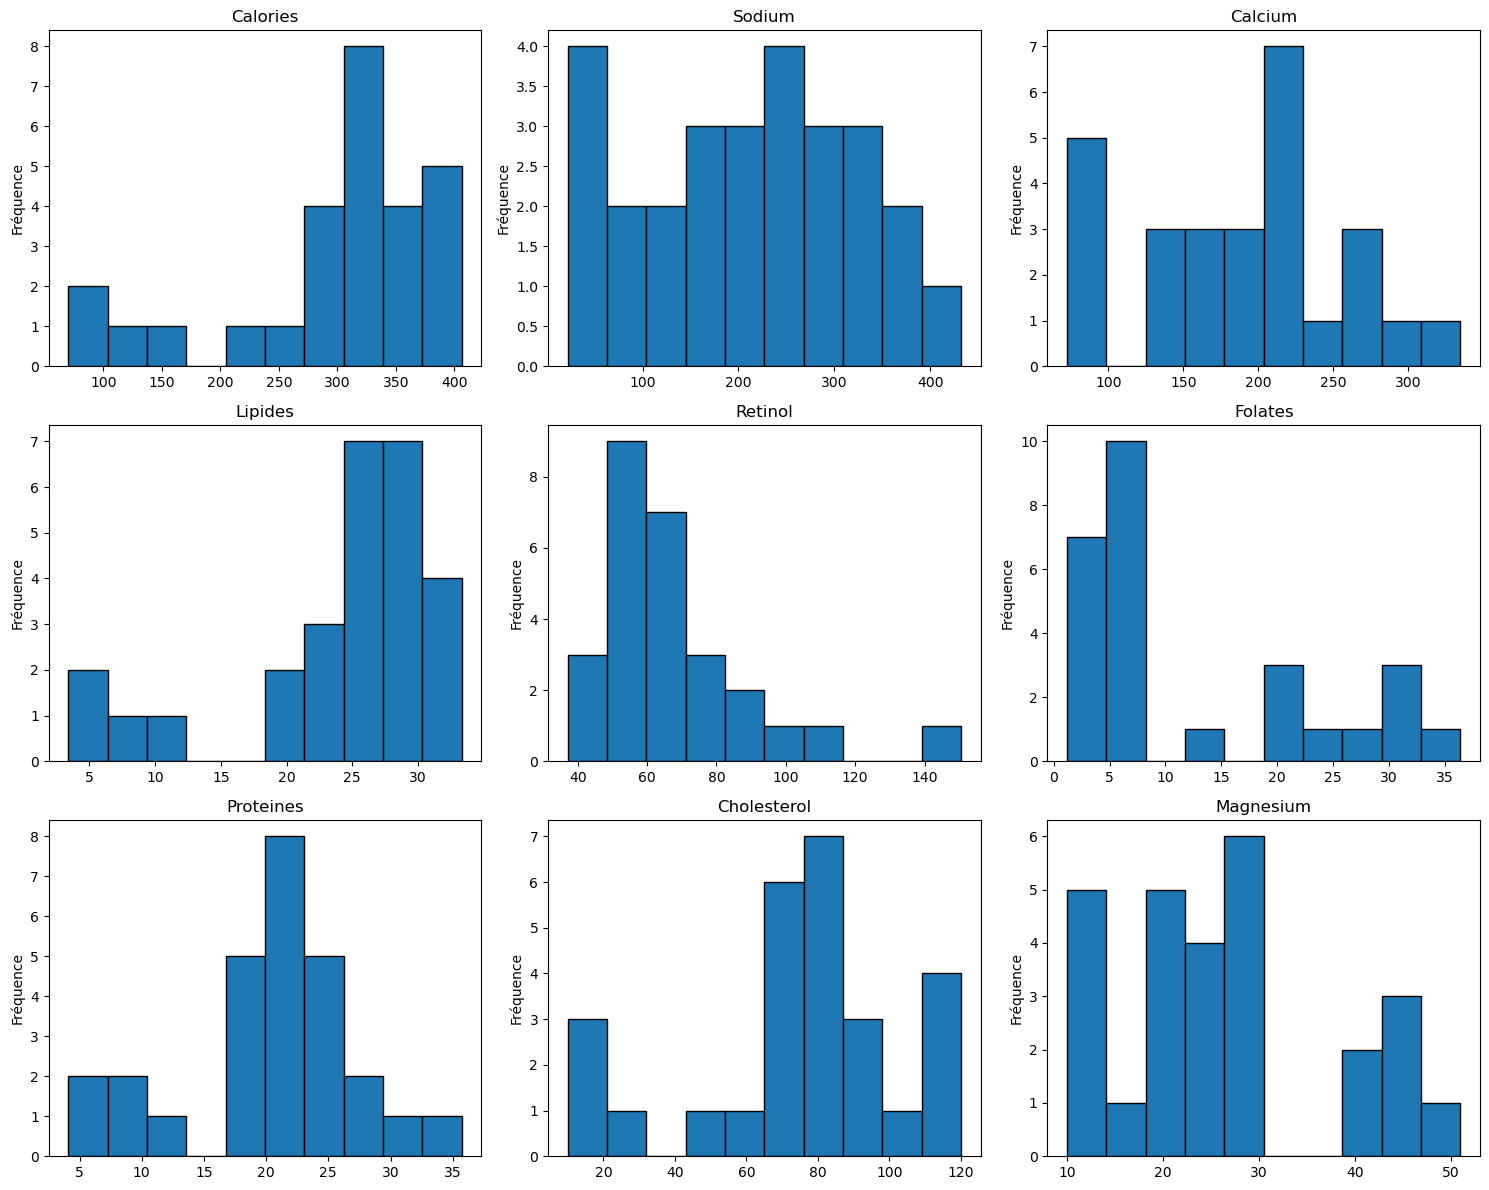

In [6]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(X1.columns):
    axes[i].hist(X1[col], bins=10, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

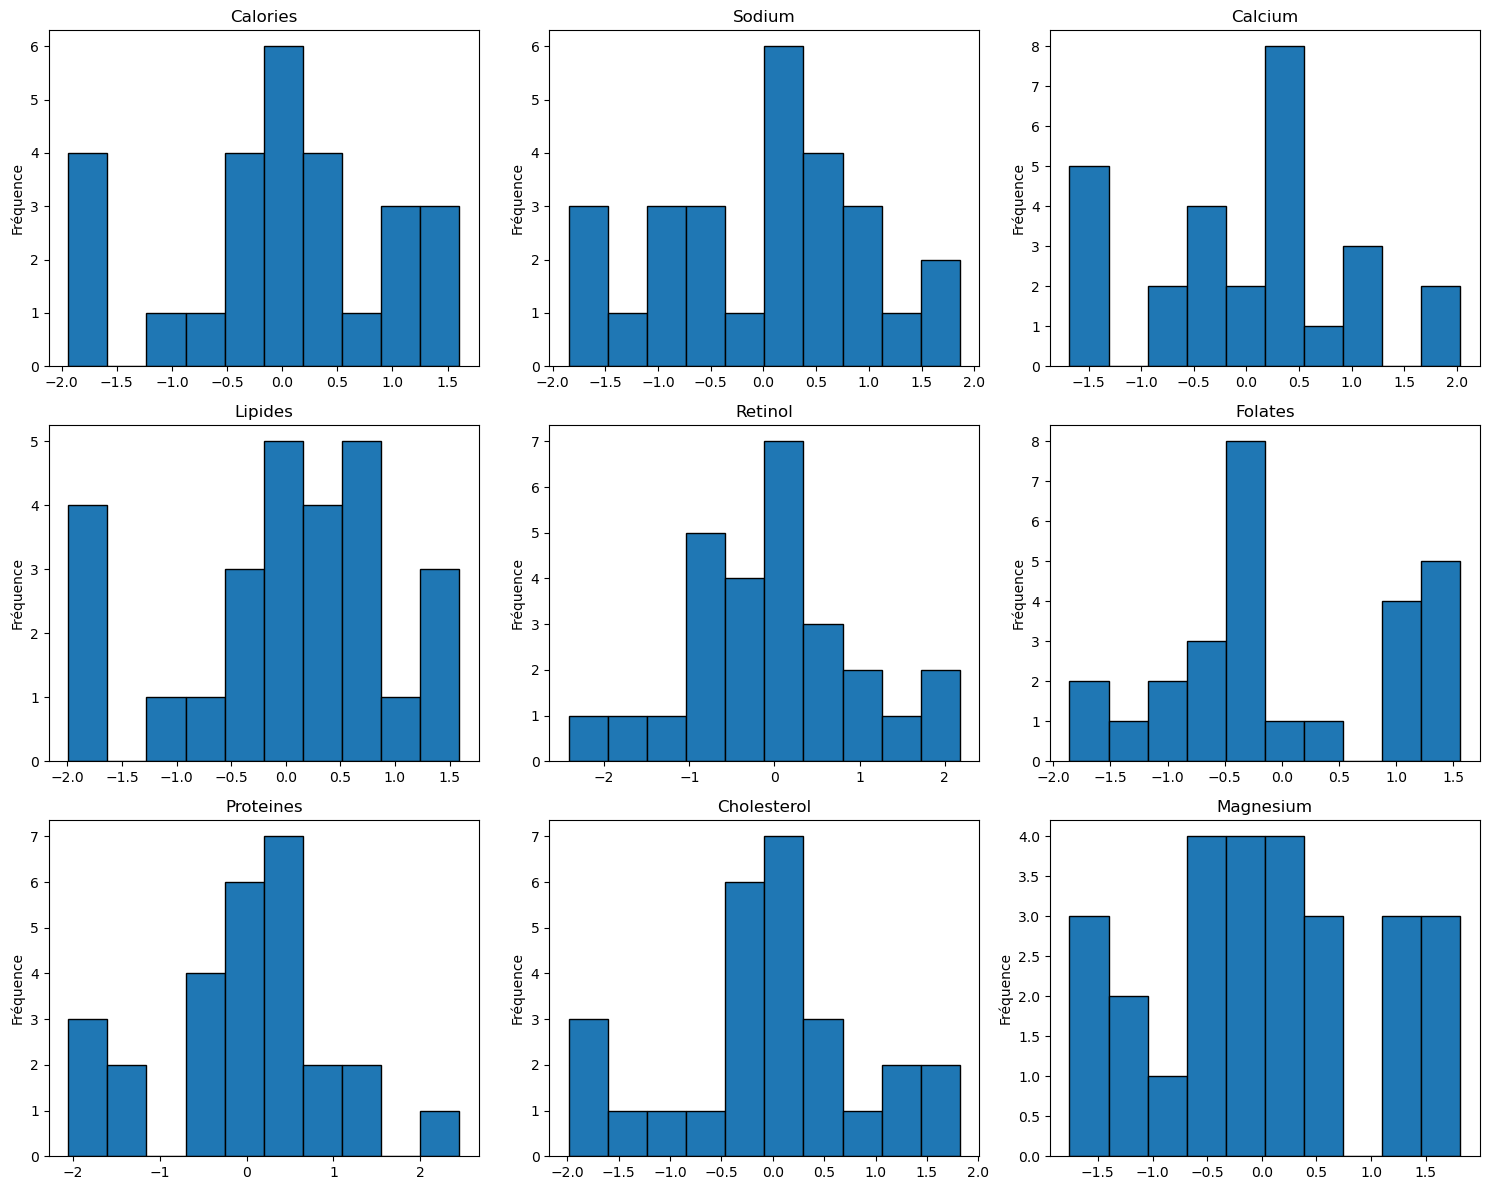

In [7]:
import numpy as np 
from sklearn.preprocessing import PowerTransformer
YJ = PowerTransformer(method='yeo-johnson', standardize=True)
X3 = YJ.fit_transform(X1)
X3=pd.DataFrame(data=X3,columns=X1.columns, index=X1.index)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for i, col in enumerate(X3.columns):
    axes[i].hist(X3[col], bins=10, edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

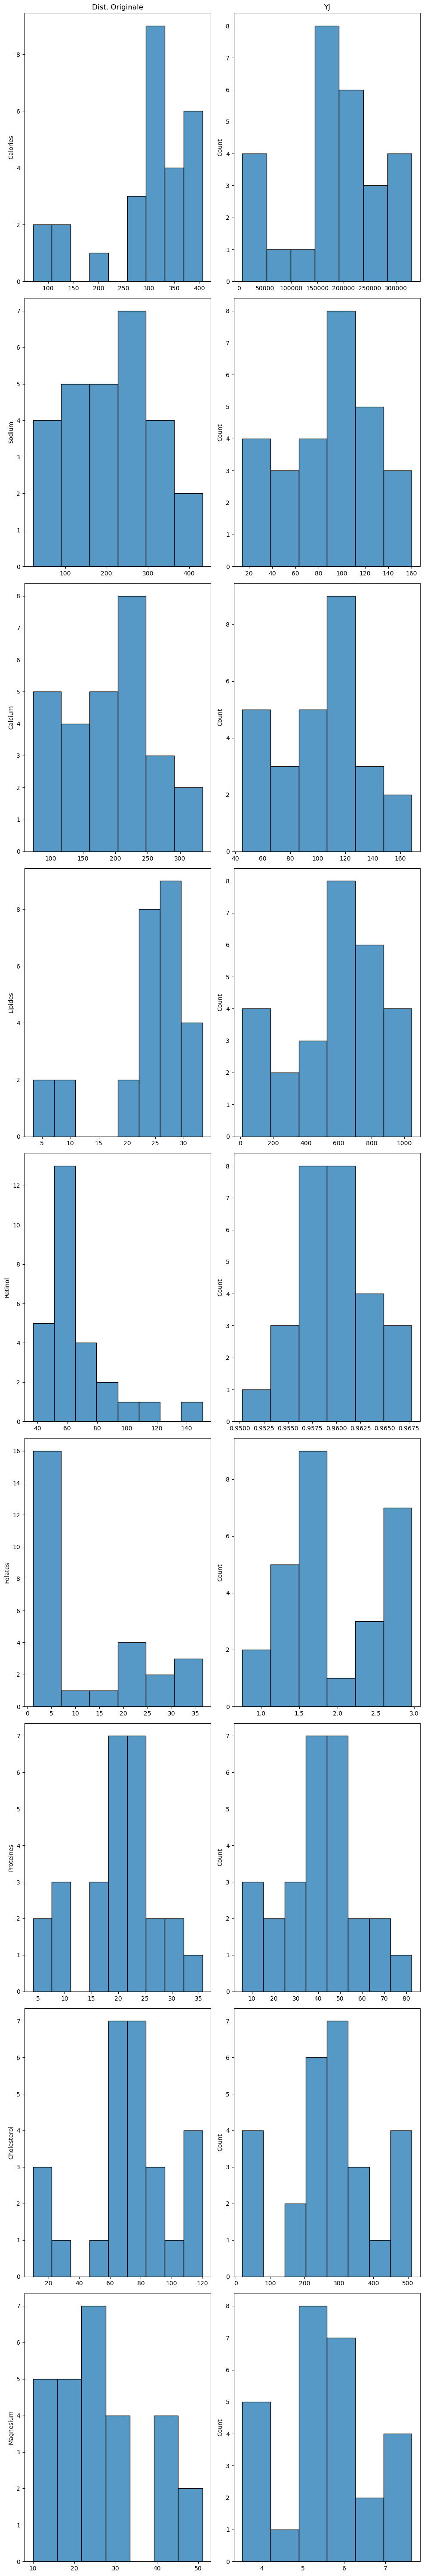

In [18]:

import warnings
from sklearn.preprocessing import StandardScaler, RobustScaler
from scipy.stats import yeojohnson

# transformations
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)

    # colonnes d'interet
    coi = X1

    _, axes = plt.subplots(coi.shape[1], 2, figsize=(10, 60))

    for col_index, col_name in enumerate(coi):
        dist = coi[col_name]

        axes[col_index, 0].set_ylabel(col_name)

        # normal dist
        sns.histplot(dist.to_numpy(), ax=axes[col_index, 0])

        # yeojohnson 
        w_dist, _  = yeojohnson(dist)
        sns.histplot(w_dist, ax=axes[col_index, 1])

    axes[0, 0].set_title("Dist. Originale")
    axes[0, 1].set_title("YJ")

    plt.tight_layout()
    plt.show()

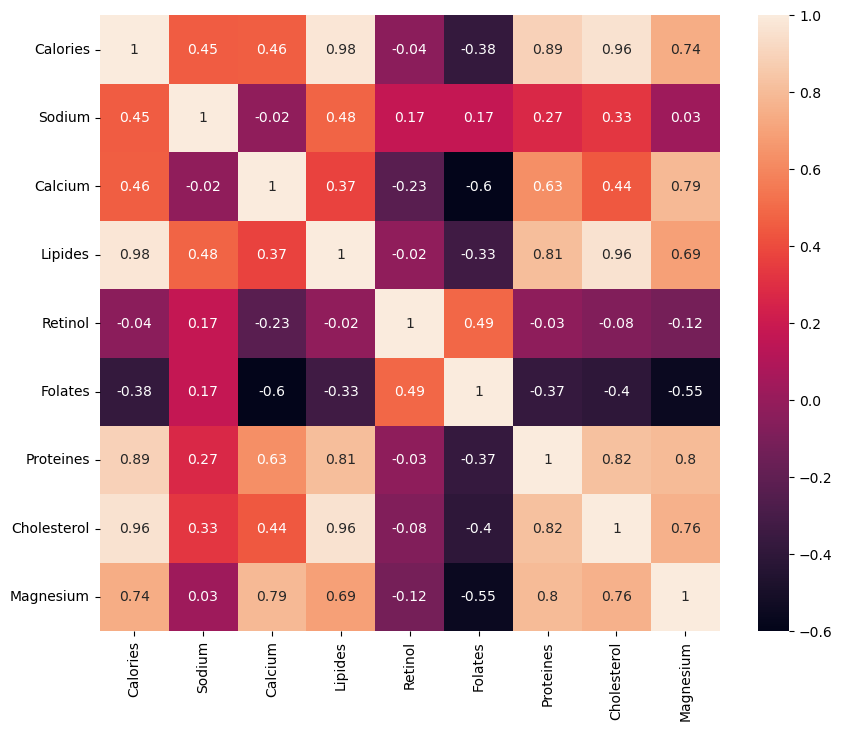

In [19]:
import matplotlib.pyplot as plt


corr=X1.corr()
corr=corr.round(2)
f,ax = plt.subplots(figsize=(10,8))
sns.heatmap(corr,annot=True)
plt.show()

In [20]:
#Standardiser les données de X1

In [21]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
Z = StandardScaler().fit_transform(X1)
Z1 = pd.DataFrame(data = Z, columns = X1.columns,index=X1.index)
Z1.head()

,Calories,Sodium,Calcium,Lipides,Retinol,Folates,Proteines,Cholesterol,Magnesium
Fromages,,,,,,,,,
CarreDelEst,0.195965,1.310033,-1.632229,0.299260,-0.660632,1.631613,0.128963,-0.133472,-0.573287
Babybel,0.195965,0.262510,0.334153,0.152794,-0.155415,-0.549166,0.355435,-0.133472,0.042345
Beaufort,1.139247,-0.880241,1.045032,1.153642,-0.522846,-1.023645,0.921614,1.615922,1.273609
Bleu,0.499550,1.151317,0.352785,0.616601,-1.266056,1.376124,0.015727,0.566286,0.042345
Camembert,-0.346151,0.951789,0.421580,-0.530711,1.485494,2.188214,0.468670,-0.483351,-0.573287


In [22]:
#vérification moyennes et déviations standards

In [23]:
import numpy
print(numpy.mean(Z1,axis=0))


Calories       1.644775e-17
Sodium         8.223874e-17
Calcium       -2.364364e-16
Lipides        4.276415e-16
Retinol       -3.782982e-16
Folates        1.480297e-16
Proteines      6.579099e-17
Cholesterol    1.973730e-16
Magnesium     -6.579099e-17
dtype: float64


In [24]:
print(numpy.std(Z1,axis=0,ddof=0))

Calories       1.0
Sodium         1.0
Calcium        1.0
Lipides        1.0
Retinol        1.0
Folates        1.0
Proteines      1.0
Cholesterol    1.0
Magnesium      1.0
dtype: float64


In [25]:
#Données catégorielles ajoutées

In [56]:
X_cat = pd.get_dummies(X2,dtype=int)
X_cat.head()


,Type_pate molle,Type_pate pressee cuite,Type_pate pressee noncuite
Fromages,,,
CarreDelEst,1,0,0
Babybel,0,0,1
Beaufort,0,1,0
Bleu,1,0,0
Camembert,1,0,0


In [57]:
# Transformation en tenant compte des fréquences des modalités

In [28]:
n = X_cat.shape[0]
ponderation = np.sqrt((X_cat.sum(axis=0)) / n)
X3 = X_cat / ponderation

X3.head()

,Type_pate molle,Type_pate pressee cuite,Type_pate pressee noncuite
Fromages,,,
CarreDelEst,1.341641,0.00000,0.000000
Babybel,0.000000,0.00000,1.963961
Beaufort,0.000000,2.32379,0.000000
Bleu,1.341641,0.00000,0.000000
Camembert,1.341641,0.00000,0.000000


In [29]:
Xfin = Z1.join(X3)
Xfin.index = X.index
Xfin.head()

,Calories,Sodium,Calcium,Lipides,Retinol,Folates,Proteines,Cholesterol,Magnesium,Type_pate molle,Type_pate pressee cuite,Type_pate pressee noncuite
Fromages,,,,,,,,,,,,
CarreDelEst,0.195965,1.310033,-1.632229,0.299260,-0.660632,1.631613,0.128963,-0.133472,-0.573287,1.341641,0.00000,0.000000
Babybel,0.195965,0.262510,0.334153,0.152794,-0.155415,-0.549166,0.355435,-0.133472,0.042345,0.000000,0.00000,1.963961
Beaufort,1.139247,-0.880241,1.045032,1.153642,-0.522846,-1.023645,0.921614,1.615922,1.273609,0.000000,2.32379,0.000000
Bleu,0.499550,1.151317,0.352785,0.616601,-1.266056,1.376124,0.015727,0.566286,0.042345,1.341641,0.00000,0.000000
Camembert,-0.346151,0.951789,0.421580,-0.530711,1.485494,2.188214,0.468670,-0.483351,-0.573287,1.341641,0.00000,0.000000


In [30]:
import sklearn as sk

In [31]:
from sklearn.decomposition import PCA

In [32]:
print(PCA)

<class 'sklearn.decomposition._pca.PCA'>


In [33]:
acp=PCA(svd_solver='full')
print(acp)

PCA(svd_solver='full')


In [34]:
coord1=acp.fit_transform(Xfin)

In [35]:
print(coord1)

[[-1.01947607e+00  2.03435455e+00 -4.86848841e-02 -1.37094647e+00
  -3.82387204e-01  1.08101817e+00 -1.07856876e-01  2.28835182e-01
   5.75409095e-01  1.42378223e-02  1.02899963e-02  1.95979816e-17]
 [ 7.32830400e-01 -4.53622598e-01  1.52048399e+00  2.60939176e-01
  -5.62389345e-01 -8.39859891e-02 -3.20251071e-01 -4.59968172e-02
   1.42474088e-01 -6.02187483e-04  7.36416836e-03  2.04594958e-16]
 [ 3.36500442e+00 -9.68542630e-01 -1.70002657e+00 -3.87851245e-02
  -1.12137540e-01 -3.90420568e-03  6.09285535e-02 -2.40090821e-01
  -2.67883041e-01  8.40156550e-03 -2.93234724e-02 -3.27122100e-16]
 [ 3.57844920e-01  1.23521021e+00  1.77621477e-01 -1.45458310e+00
   8.19804601e-01  1.34447814e+00  9.22566355e-02 -5.97995234e-01
  -2.21663498e-01 -4.76808492e-02  2.63855093e-02 -1.22734534e-17]
 [-1.27644428e+00  2.02171425e+00  5.03761310e-02  1.21745061e+00
   1.17386353e+00  8.78990254e-01 -7.83628933e-01  3.80663979e-02
  -2.84375419e-01  1.07728672e-01 -4.55682238e-02  1.41186422e-16]
 [-1.

In [36]:
print(acp.explained_variance_ratio_)

[5.14321043e-01 1.79538607e-01 1.02227263e-01 8.21410186e-02
 5.20810298e-02 3.25879607e-02 1.88551174e-02 1.01707999e-02
 6.18852979e-03 1.65077372e-03 2.37857071e-04 3.96372280e-33]


In [37]:
# On a 70% de la variance expliquée sur 2 axes et 80% sur 3 axes

In [38]:
# Les Valeurs propres
eigval = acp.explained_variance_
print([eigval])

[array([5.87512883e+00, 2.05088332e+00, 1.16774989e+00, 9.38303174e-01,
       5.94925610e-01, 3.72254782e-01, 2.15383457e-01, 1.16181830e-01,
       7.06920519e-02, 1.88569152e-02, 2.71705962e-03, 4.52779104e-32])]


In [39]:
#On a les 3 prmières CP OK

#On va regarder l'évolution des VP en fonction des composantes principales

12
[ 0  1  2  3  4  5  6  7  8  9 10 11]
[5.87512883e+00 2.05088332e+00 1.16774989e+00 9.38303174e-01
 5.94925610e-01 3.72254782e-01 2.15383457e-01 1.16181830e-01
 7.06920519e-02 1.88569152e-02 2.71705962e-03 4.52779104e-32]


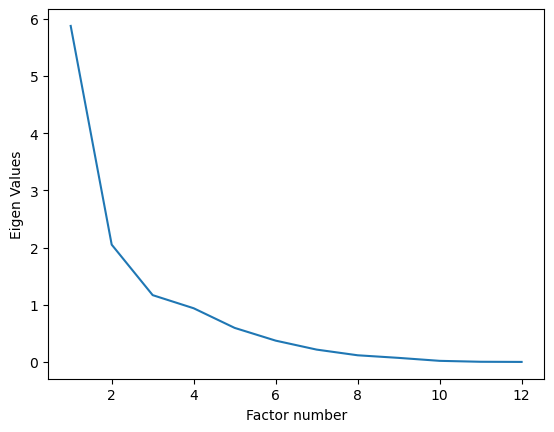

In [40]:
#nombre de variables
p = Xfin.shape[1]
print(p)
nunu=np.arange(p)
print(nunu)
print(eigval)
#nombre d'observations
n = Xfin.shape[0]
#matrice des X
X = Xfin.values

import matplotlib.pyplot as plt
plt.plot(np.arange(1, p+1), eigval)
plt.ylabel("Eigen Values")
plt.xlabel("Factor number")
plt.show()

In [41]:
#Seuils à appliquer (si non visuel)
p = Xfin.shape[1]
bs = 1/numpy.arange(p,0,-1)
bs = numpy.cumsum(bs)
# on fait 1/5 + 1/4 + 1/3 + 1/2 + 1
bs = bs[::-1]

In [42]:
print(pd.DataFrame({'Val.Propre':eigval,'Seuils':bs}))

      Val.Propre    Seuils
0   5.875129e+00  3.103211
1   2.050883e+00  2.103211
2   1.167750e+00  1.603211
3   9.383032e-01  1.269877
4   5.949256e-01  1.019877
5   3.722548e-01  0.819877
6   2.153835e-01  0.653211
7   1.161818e-01  0.510354
8   7.069205e-02  0.385354
9   1.885692e-02  0.274242
10  2.717060e-03  0.174242
11  4.527791e-32  0.083333


In [43]:
# On va regarder sur 2 CP (90% déjà de variance expliquée) 

acp=PCA(n_components=2,svd_solver='full')
coord=acp.fit_transform(Xfin)
print(coord)

[[-1.01947607  2.03435455]
 [ 0.7328304  -0.4536226 ]
 [ 3.36500442 -0.96854263]
 [ 0.35784492  1.23521021]
 [-1.27644428  2.02171425]
 [-1.23062655  2.44490388]
 [ 2.32651733  0.19333798]
 [ 3.59845484 -0.98227841]
 [-1.11360587  1.28396221]
 [ 1.77955696 -1.19838065]
 [ 3.36740869 -1.59631999]
 [-3.27250805  2.06336306]
 [-0.51908559  1.11581515]
 [-4.57394785 -2.05557136]
 [-4.39940827 -1.23394691]
 [ 1.39487755  0.11516967]
 [ 1.76184532 -0.16863277]
 [ 3.07687418 -0.21253902]
 [-4.19016711 -1.15842401]
 [-0.29796894 -0.10720521]
 [ 1.12618353 -0.21865866]
 [ 0.19660216  0.49423112]
 [ 0.62582757  2.36273042]
 [ 0.77933966 -0.94785747]
 [ 0.38773801  0.12689112]
 [ 0.97279174 -1.21224477]
 [-3.9564587  -2.97745916]]


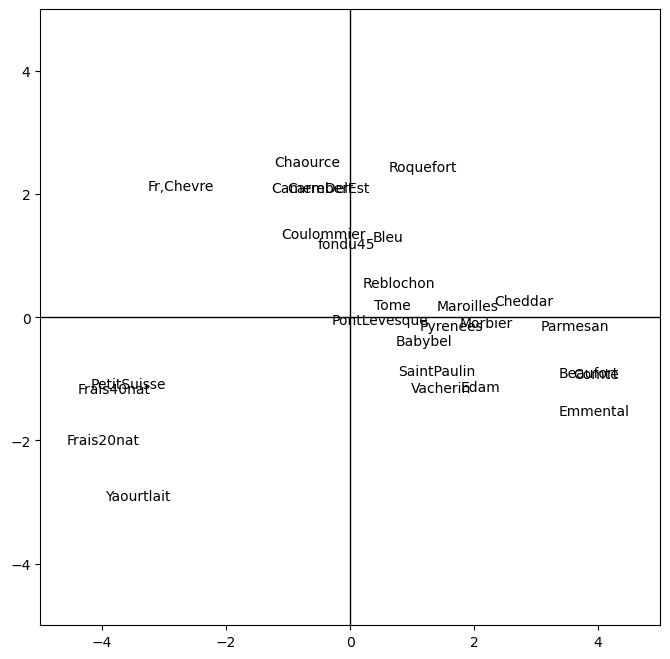

In [44]:
f,ax = plt.subplots(figsize=(8,8))
#fig, axes = plt.plot(figsize=(10,10))
ax.set_xlim(-5,5)
ax.set_ylim(-5,5)
n = Xfin.shape[0]
for i in range(n):
    plt.annotate(Xfin.index[i],(coord[i,0],coord[i,1]))
plt.plot([-5,5],[0,0],color='black',linestyle='-',linewidth=1)
plt.plot([0,0],[-5,5],color='black',linestyle='-',linewidth=1)
plt.show()

In [48]:
# Poids des variables initiales sur les axes

In [45]:
#On lance l'ACP avec toutes les composantes:
acp=PCA(svd_solver='full')
coord=acp.fit_transform(Xfin)

#racine carrée des valeurs propres
sqrt_eigval = numpy.sqrt(eigval)

#corrélation des variables avec les axes
corvar = numpy.zeros((p,p))
for k in range(p):
 corvar[:,k] = acp.components_[k,:] * sqrt_eigval[k]
 
#afficher la matrice des corrélations variables x facteurs 
print(corvar)

[[ 9.52241437e-01  3.26750843e-01 -9.90443671e-03 -7.87819990e-02
  -1.14132870e-01  1.97310028e-02  2.48857235e-02  1.77142313e-02
  -3.81734350e-02 -3.08855571e-02  4.32102111e-02  0.00000000e+00]
 [ 2.34726313e-01  7.84581270e-01  3.63436356e-01 -3.41434793e-01
   2.37156756e-01 -1.47355211e-01 -1.79470713e-01 -3.22374032e-02
   8.47220997e-02  2.73582598e-02 -1.20177077e-03 -6.03336711e-32]
 [ 7.17113602e-01 -3.98926546e-01  1.95242732e-01  2.08317763e-01
   4.97370329e-01  4.05714437e-02 -1.08119473e-01 -1.00146939e-01
  -1.11580723e-01 -1.89311001e-02 -2.36226541e-04  3.33870028e-32]
 [ 9.05379832e-01  3.91656367e-01 -3.01819285e-02 -1.27523039e-01
  -1.67825589e-01 -1.99029054e-02  6.85952406e-02 -8.01755952e-02
  -1.02859673e-02 -8.80788658e-02 -2.49487325e-02 -1.03971531e-32]
 [-1.83021413e-01  5.96672143e-01 -9.58667121e-02  7.49335475e-01
   1.59705478e-03 -2.78942050e-01  6.55458862e-03  9.05627377e-03
  -1.77977026e-02 -1.34785473e-04 -1.09586841e-05 -1.55012310e-32]
 [-6.

In [46]:
#on affiche pour les deux premiers axes
print(pd.DataFrame({'id':Xfin.columns,'COR_1':corvar[:,0],'COR_2':corvar[:,1]}))

                            id     COR_1     COR_2
0                     Calories  0.952241  0.326751
1                       Sodium  0.234726  0.784581
2                      Calcium  0.717114 -0.398927
3                      Lipides  0.905380  0.391656
4                      Retinol -0.183021  0.596672
5                      Folates -0.610488  0.616478
6                    Proteines  0.931021  0.145821
7                  Cholesterol  0.936346  0.253553
8                    Magnesium  0.908410 -0.152206
9              Type_pate molle -0.495491  0.275246
10     Type_pate pressee cuite  0.531688 -0.219835
11  Type_pate pressee noncuite  0.275966 -0.217124


In [63]:
#Cela indique les variables qui pèsent le plus sur les axes


#Comment projeter de nouveaux fromages?



           Calories    Sodium   Calcium   Lipides   Retinol   Folates  \
Fromages                                                                
Cantal     0.770608  0.425761  1.110961  0.604396 -0.777541 -0.613038   
Chabichou  0.521235 -0.154685 -1.422979  0.494547  0.946875  2.179089   

           Proteines  Cholesterol  Magnesium  Type_pate molle  \
Fromages                                                        
Cantal      0.412053     0.566286   0.306187         0.000000   
Chabichou  -0.083354     0.216407   0.833872         1.341641   

           Type_pate pressee cuite  Type_pate pressee noncuite  
Fromages                                                        
Cantal                         0.0                    1.963961  
Chabichou                      0.0                    0.000000  


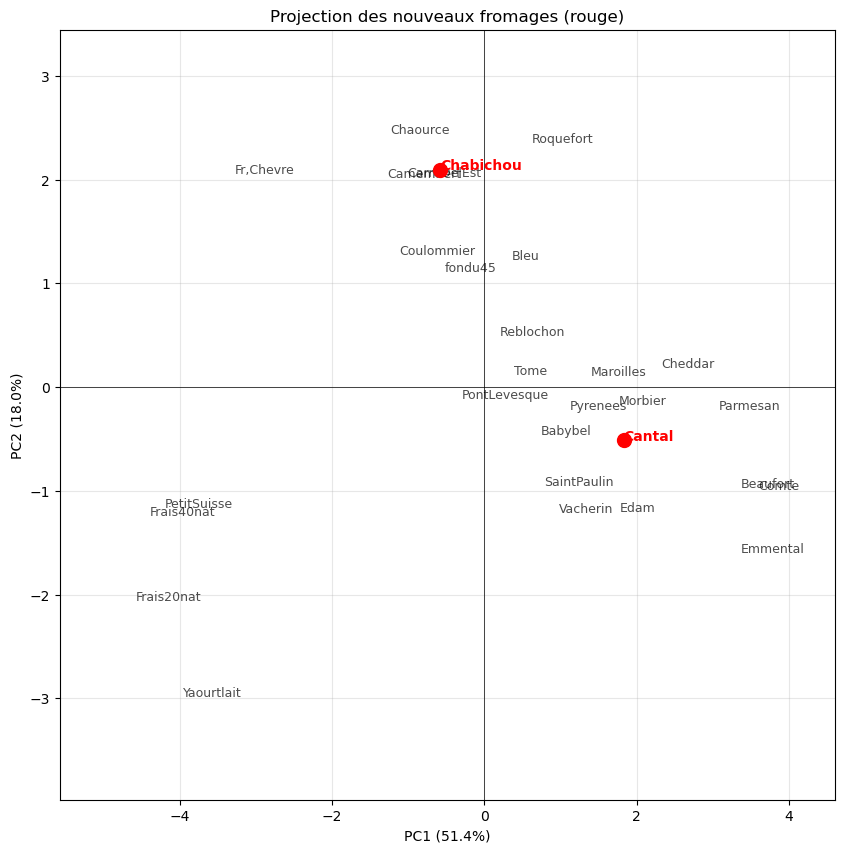

Coordonnées des nouveaux fromages :
                PC1       PC2
Fromages                     
Cantal     1.826912 -0.511039
Chabichou -0.576972  2.097435


In [91]:

# On va centrer et réduire les variables supplémentaires AVEC LES PARAMETRES moy ET Sigma des données initiales


# Nouveaux fromages
X_new = pd.read_csv("Fromages_Dataset1Bis.csv", delimiter=";", index_col=0)

# Séparer numériques et catégoriel
X_num_new = X_new.select_dtypes(exclude=['object'])
X_cat_new = X_new.select_dtypes(include=['object'])

# Standardiser avec les mêmes paramètres que le dataset d'entraînement
sc = StandardScaler()
Z = sc.fit_transform(X1)
Z1 = pd.DataFrame(data = Z, columns = X1.columns,index=X1.index)

Z_new = sc.transform(X_num_new)
Z1_new = pd.DataFrame(Z_new,columns = X_num_new.columns,index=X_num_new.index)

# Transformer la variable catégorielle avec les mêmes colonnes que l'entraînement
X_cat_dummy_new = pd.get_dummies(X_cat_new,dtype=int)
# Aligner les colonnes avec celles de l'entraînement
X_cat_dummy_new = X_cat_dummy_new.reindex(columns=X_cat.columns,fill_value="0")

X_cat_dummy_new = (X_cat_dummy_new).astype(int)

X_cat = pd.get_dummies(X2,dtype=int)
ponderation = np.sqrt((X_cat.sum(axis=0)) / n)

X_cat_norm_new = (X_cat_dummy_new) / ponderation
X_cat_norm_new = pd.DataFrame(X_cat_norm_new)

# final
X_complet_new = Z1_new.join(X_cat_norm_new)
print(X_complet_new)
X_complet_new= pd.DataFrame(X_complet_new)

X_complet_new.index = X_new.index

# Projeter sur les 2 premières CP
acp=PCA(n_components=2,svd_solver='full')
coord=acp.fit_transform(Xfin)
coord_new = acp.transform(X_complet_new)

# Visualiser avec les fromages originaux
fig, ax = plt.subplots(figsize=(10, 10))
ax.set_xlim(coord[:, 0].min()-1, coord[:, 0].max()+1)
ax.set_ylim(coord[:, 1].min()-1, coord[:, 1].max()+1)

# Fromages originaux
for i in range(len(Xfin)):
    plt.annotate(Xfin.index[i], (coord[i, 0], coord[i, 1]), fontsize=9, alpha=0.7)

# Nouveaux fromages en rouge
for i in range(len(X_complet_new)):
    plt.scatter(coord_new[i, 0], coord_new[i, 1], color='red', s=100, zorder=5)
    plt.annotate(X_complet_new.index[i], (coord_new[i, 0], coord_new[i, 1]), 
                 fontsize=10, fontweight='bold', color='red')

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel(f'PC1 ({acp.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({acp.explained_variance_ratio_[1]:.1%})')
plt.title('Projection des nouveaux fromages (rouge)')
plt.grid(True, alpha=0.3)
plt.show()

print("Coordonnées des nouveaux fromages :")
print(pd.DataFrame(coord_new, columns=['PC1', 'PC2'], index=X_complet_new.index))

In [93]:
# Calcul des proches voisins des 2 fromages projetés
import math

for i in range(n):
    for j in range(coord_new.shape[0]):
        max= math.sqrt((coord[i,0]**2 + coord[i,1]**2))
        max1=math.sqrt((coord_new[j,0]**2 + coord_new[j,1]**2))
        distances= math.sqrt((coord[i,0] - coord_new[j,0])**2+ (coord[i,1] - coord_new[j,1])**2)
        print(X1.index[i],"  ","initial",max,"          ",X_new.index[j],"  ","initial","   ",max1,"distance","      ",distances)


CarreDelEst    initial 2.2755065115436803            Cantal    initial     1.8970423003865122 distance        3.8185017159284906
CarreDelEst    initial 2.2755065115436803            Chabichou    initial     2.175346195579667 distance        0.44697742048902184
Babybel    initial 0.8618664955440614            Cantal    initial     1.8970423003865122 distance        1.0955874545655164
Babybel    initial 0.8618664955440614            Chabichou    initial     2.175346195579667 distance        2.8676607960361316
Beaufort    initial 3.501618140033705            Cantal    initial     1.8970423003865122 distance        1.604692146360517
Beaufort    initial 3.501618140033705            Chabichou    initial     2.175346195579667 distance        4.993936273937021
Bleu    initial 1.286000481455595            Cantal    initial     1.8970423003865122 distance        2.282004698462004
Bleu    initial 1.286000481455595            Chabichou    initial     2.175346195579667 distance        1.27173696632